In [1]:
# Google Colab instructions
# Runtime > Change Runtime Type > Runtime Version > 2025.07
# This cell should say you're now on Python Version 3.11.

import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [2]:
!pip install pycaret openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.2 MB/s eta 0:00:00


In [1]:
# Before running: Runtime > Restart Session

from pycaret.regression import *

In [33]:
import pandas as pd

df = pd.read_excel("sipri_data1.xlsx")

In [25]:
#df = df.dropna(subset=['ME_spending_%_GDP_lead_1_year'])

#Military Expenditure as Percentage of GDP Regression

In [34]:
regression_pipeline = setup(
    data=df,
    target='ME_spending_%_GDP',
    categorical_features=['top_supplier_country'],
    ignore_features=[
        'country',
        'import_TIV_millions',
        'ME_spending_%_GDP_lead_1_year',
        'ME_per_capita_in_USD',
        'ME_%_gov_budget',
        'ME_spending_%_GDP_growth_rate',
        'import_growth_rate',
        'import_export_ratio',
    ],
    numeric_imputation='median',
    categorical_imputation='constant',
    session_id=42,
    train_size=0.8
)

,Description,Value
0,Session id,42
1,Target,ME_spending_%_GDP
2,Target type,Regression
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(180, 34)"
5,Transformed train set shape,"(144, 34)"
6,Transformed test set shape,"(36, 34)"
7,Ignore features,8
8,Numeric features,9
9,Categorical features,1


In [35]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,0.0057,0.0001,0.0098,0.5079,0.0088,0.3257,0.0940
ada,AdaBoost Regressor,0.0082,0.0001,0.0116,0.2021,0.0107,0.7196,0.1240
huber,Huber Regressor,0.0119,0.0018,0.0271,-0.0712,0.0238,0.5070,0.0850
dummy,Dummy Regressor,0.0147,0.0019,0.0288,-0.4510,0.0256,1.0468,0.0550
llar,Lasso Least Angle Regression,0.0153,0.0018,0.0289,-0.8076,0.0250,0.8753,0.0560
lasso,Lasso Regression,0.0153,0.0018,0.0289,-0.8076,0.0250,0.8753,0.0970
en,Elastic Net,0.0155,0.0018,0.0292,-0.9256,0.0251,0.8741,0.0690
et,Extra Trees Regressor,0.0081,0.0005,0.0172,-0.9836,0.0150,0.4036,0.2360
omp,Orthogonal Matching Pursuit,0.0158,0.0018,0.0296,-1.1145,0.0254,0.8683,0.0570
lightgbm,Light Gradient Boosting Machine,0.0160,0.0018,0.0319,-2.0102,0.0281,0.8871,0.0900


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [36]:
xgboost_model = create_model('xgboost')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0030,0.0000,0.0038,0.6820,0.0037,0.2042
1,0.0019,0.0000,0.0026,0.9094,0.0026,0.1834
2,0.0062,0.0001,0.0092,0.5421,0.0090,0.3758
3,0.0041,0.0000,0.0060,0.1353,0.0059,0.3519
4,0.0088,0.0003,0.0177,0.9672,0.0135,0.3247
5,0.0078,0.0002,0.0138,0.0141,0.0134,0.3049
6,0.0068,0.0001,0.0108,0.6018,0.0105,0.6693
7,0.0061,0.0001,0.0110,-0.2722,0.0106,0.3055
8,0.0068,0.0002,0.0149,0.9677,0.0113,0.1682


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [37]:
tuned_xgboost = tune_model(xgboost_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0052,0.0000,0.0063,0.1002,0.0062,0.3155
1,0.0037,0.0000,0.0051,0.6618,0.0050,0.3571
2,0.0060,0.0001,0.0088,0.5857,0.0086,0.4295
3,0.0053,0.0001,0.0076,-0.4141,0.0070,0.4207
4,0.0195,0.0031,0.0554,0.6792,0.0432,0.4193
5,0.0123,0.0004,0.0208,-1.2306,0.0196,0.4235
6,0.0051,0.0001,0.0073,0.8166,0.0071,0.7790
7,0.0060,0.0001,0.0103,-0.1277,0.0100,0.3534
8,0.0060,0.0001,0.0075,0.9919,0.0071,0.2529


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


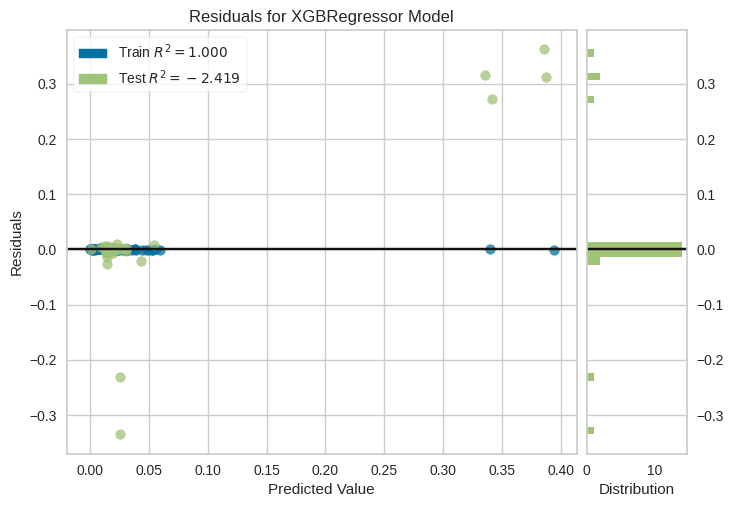

In [38]:
plot_model(tuned_xgboost, plot='residuals')

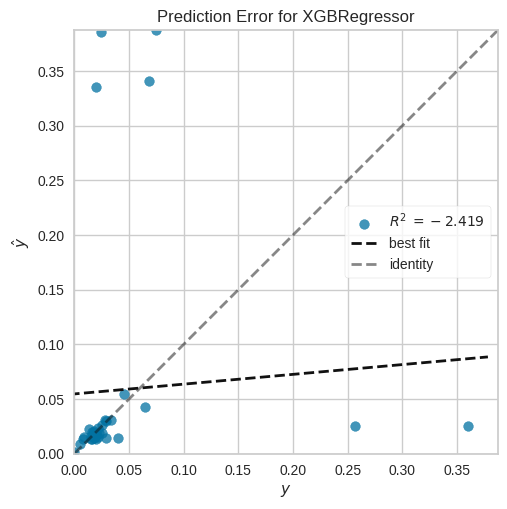

In [39]:
plot_model(tuned_xgboost, plot='error')

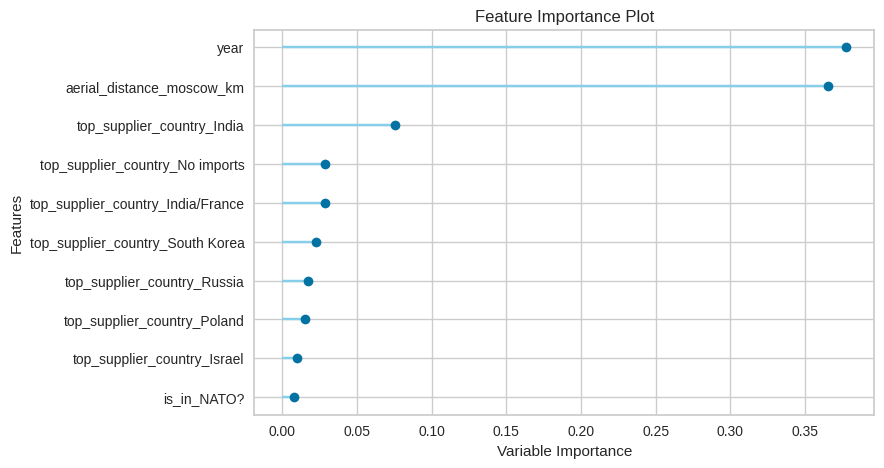

In [40]:
plot_model(tuned_xgboost, plot='feature')

In [41]:
evaluate_model(tuned_xgboost)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…